# VisDrone -- RT-DETR Training

**Objective**: Train RT-DETR (Real-Time Detection Transformer) on the merged VisDrone dataset.

**Key difference**: RT-DETR uses a transformer encoder instead of a pure CNN backbone, offering superior global context modeling which benefits crowded drone scenes. Loaded via Ultralytics as `rtdetr-r50.pt`.

**Environment**: Kaggle Notebook | GPU T4 x1 | Classes: 0=person, 1=car

---
## 1. Setup & Installation

In [1]:
!pip install -q ultralytics

import os, yaml, torch, shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import RTDETR    # RT-DETR is loaded via the RTDETR  class in Ultralytics
from pathlib import Path

print('Ultralytics:', __import__('ultralytics').__version__)
print('CUDA       :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU        :', torch.cuda.get_device_name(0))
    print('VRAM       :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.50
CUDA       : True
GPU        : Tesla T4
VRAM       : 15.6 GB


---
## 2. Model Selection & Configuration

> Change `MODEL_VARIANT` to switch RT-DETR backbones.
>
> Available via Ultralytics: `rtdetr-r18`, `rtdetr-r34`, `rtdetr-r50`, `rtdetr-r101`, `rtdetr-l`, `rtdetr-x`
>
> **T4 Note**: r50 is the recommended balance of accuracy and memory. r18/r34 are faster but less accurate.

In [2]:
# ── MODEL SELECTION ──────────────────────────────────────────────────────────
MODEL_VARIANT = 'rtdetr-l'     # OPTIONS:  'rtdetr-l' | 'rtdetr-x'
MODEL_NAME    = f'{MODEL_VARIANT}.pt'

# ── TRAINING HYPERPARAMETERS (T4-safe) ───────────────────────────────────────
# RT-DETR is heavier than YOLO; use smaller batch and/or lower imgsz if OOM
IMGSZ      = 640    # RT-DETR uses 640 natively; increase to 1280 only if VRAM allows
EPOCHS     = 50
BATCH      = 4      # Conservative for RT-DETR on T4; increase to 8 if memory permits
WORKERS    = 4
PATIENCE   = 20
LR0        = 0.0001  # Transformers prefer lower LR
LRF        = 0.00001
MOSAIC     = 0.5     # Reduce mosaic for transformer models
MIXUP      = 0.0     # DISABLED -- makes tiny objects smaller
SCALE      = 0.3     # Conservative scale jitter for transformer training
FLIPLR     = 0.5

SAVE_NAME  = f'{MODEL_VARIANT.replace("-", "_")}_visdrone'
PROJECT    = '/kaggle/working/runs'

print(f'Model       : {MODEL_NAME}')
print(f'imgsz       : {IMGSZ}')
print(f'Batch       : {BATCH}')
print(f'Epochs      : {EPOCHS}')
print(f'LR0         : {LR0}  (transformer-tuned)')
print(f'Output name : {SAVE_NAME}')

Model       : rtdetr-l.pt
imgsz       : 640
Batch       : 4
Epochs      : 50
LR0         : 0.0001  (transformer-tuned)
Output name : rtdetr_l_visdrone


---
## 3. Dataset Setup

In [3]:
# ── Dataset Remapping & Setup ──────────────────────────────────────

import os, yaml
from pathlib import Path
from tqdm.notebook import tqdm

# 1. Configuration
DATASET_PATH = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'
WORK_DIR     = Path('/kaggle/working/dataset')
YAML_PATH    = '/kaggle/working/data.yaml'

# Original VisDrone Classes: 0: pedestrian, 1: people, 3: car
REMAP = {0: 0, 1: 0, 3: 1}  # Map pedestrian & people -> person (0), car -> car (1)

SPLITS = {
    'VisDrone2019-DET-train'    : 'train',
    'VisDrone2019-DET-val'      : 'val',
    'VisDrone2019-DET-test-dev' : 'test',
}

# 2. Process Images and Labels
for visdrone_name, short in SPLITS.items():
    src_img_dir = Path(DATASET_PATH) / visdrone_name / 'images'
    src_lbl_dir = Path(DATASET_PATH) / visdrone_name / 'annotations'
    if not src_lbl_dir.exists():
        src_lbl_dir = Path(DATASET_PATH) / visdrone_name / 'labels'

    # Setup destination folders
    dst_img = WORK_DIR / 'images' / short
    dst_lbl = WORK_DIR / 'labels' / short
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    # File-by-file image symlink (Prevents YOLO from jumping to the Kaggle input dir)
    if not any(dst_img.iterdir()):
        for img_file in src_img_dir.glob('*.jpg'):
            dest_file = dst_img / img_file.name
            if not dest_file.exists():
                os.symlink(img_file, dest_file)

    # Remap and save label text files
    kept = discarded = 0
    label_files = sorted(src_lbl_dir.glob('*.txt'))

    for lf in tqdm(label_files, desc=short):
        out_lines = []
        for line in lf.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            
            cls = int(parts[0])
            if cls in REMAP:
                out_lines.append(f"{REMAP[cls]} {' '.join(parts[1:])}")
                kept += 1
            else:
                discarded += 1
                
        # Write the new remapped label
        (dst_lbl / lf.name).write_text('\n'.join(out_lines))

    print(f'  [{short}] kept={kept:,} | discarded={discarded:,} '
          f'({kept/max(kept+discarded, 1)*100:.1f}% retained)')

# 3. Create the final, single YAML file
data_yaml = {
    'path'  : str(WORK_DIR),       # Points straight to your new processed folder
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : 2,
    'names' : {0: 'person', 1: 'car'}
}

with open(YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f'\nDataset ready! Single configuration saved to: {YAML_PATH}')


train:   0%|          | 0/6471 [00:00<?, ?it/s]

  [train] kept=251,263 | discarded=91,942 (73.2% retained)


val:   0%|          | 0/548 [00:00<?, ?it/s]

  [val] kept=28,033 | discarded=10,726 (72.3% retained)


test:   0%|          | 0/1610 [00:00<?, ?it/s]

  [test] kept=55,456 | discarded=19,646 (73.8% retained)

Dataset ready! Single configuration saved to: /kaggle/working/data.yaml


---
## 4. Training

In [4]:
# RT-DETR is loaded via Ultralytics YOLO class
model = RTDETR(MODEL_NAME)
print(f'Loaded: {MODEL_NAME}')
print('Architecture type:', type(model.model).__name__)

Loaded: rtdetr-l.pt
Architecture type: DetectionModel


In [5]:
results = model.train(
    data      = YAML_PATH,
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    workers   = WORKERS,
    patience  = PATIENCE,
    lr0       = LR0,
    lrf       = LRF,
    mosaic    = MOSAIC,
    mixup     = MIXUP,
    scale     = SCALE,
    fliplr    = FLIPLR,
    name      = SAVE_NAME,
    project   = PROJECT,
    save      = True,
    plots     = True,
    verbose   = True,
   
)

print('Training complete.')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=rtdetr_l_visdrone, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      5.74G      1.267     0.3649     0.7377         54        640: 100% ━━━━━━━━━━━━ 1618/1618 2.5it/s 10:46
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 4.7it/s 14.7s
                   all        548      28033        0.7      0.577      0.602       0.34

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      5.93G      1.125     0.4158     0.1527        155        640: 0% ──────────── 0/1618  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      5.94G     0.9346     0.4218     0.1064        108        640: 100% ━━━━━━━━━━━━ 1618/1618 2.6it/s 10:23
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 5.6it/s 12.3s
                   all        548      28033      0.708      0.589      0.616      0.348

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      5.94G     0.6134      0.441    0.09674        106        640: 0% ──────────── 0/1618  0.4s

...

      48/50      8.36G     0.6006     0.4197    0.04638         99        640: 100% ━━━━━━━━━━━━ 1618/1618 2.6it/s 10:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 5.6it/s 12.3s
                   all        548      28033       0.79      0.695      0.745      0.442

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      49/50      3.74G     0.3788     0.3843    0.04469         82        640: 0% ──────────── 0/1618  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      11.8G     0.5958     0.4174     0.0453         76        640: 100% ━━━━━━━━━━━━ 1618/1618 2.6it/s 10:20
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 5.6it/s 12.2s
                   all        548      28033      0.792      0.695      0.744      0.443

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50       3.7G     0.6146     0.4243    0.03337        104        640: 0% ──────────── 0/1618  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50      10.4G     0.5952     0.4161     0.0454         99        640: 100% ━━━━━━━━━━━━ 1618/1618 2.6it/s 10:21
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 5.6it/s 12.3s
                   all        548      28033       0.79      0.697      0.746      0.445

50 epochs completed in 8.820 hours.
Optimizer stripped from /kaggle/working/runs/rtdetr_l_visdrone/weights/last.pt, 66.2MB
Optimizer stripped from /kaggle/working/runs/rtdetr_l_visdrone/weights/best.pt, 66.2MB

Validating /kaggle/working/runs/rtdetr_l_visdrone/weights/best.pt...
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 4.8it/s 14.3s
                   all        548      28033      0.791      0.696      0.746      0.445
 

---
## 5. Validation

In [6]:
best_weights = Path(PROJECT) / SAVE_NAME / 'weights' / 'best.pt'
model_val = RTDETR(str(best_weights))
val_results = model_val.val(data=YAML_PATH, imgsz=IMGSZ, batch=BATCH)

print('=== Validation Results ===')
print(f'mAP50     : {val_results.box.map50:.4f}')
print(f'mAP50-95  : {val_results.box.map:.4f}')
print(f'Precision : {val_results.box.mp:.4f}')
print(f'Recall    : {val_results.box.mr:.4f}')

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,987,850 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 164.5±96.9 MB/s, size: 126.7 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 191.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 4.7it/s 29.3s
                   all        548      28033      0.791      0.697      0.747      0.447
                person        531      13969      0.761      0.568      0.638      0.287
                   car        515      14064      0.822      0.826      0.856      0.607
Speed: 0.9ms preprocess, 47.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
=== Validation Results ===
mAP50     : 0.7469
mAP50-95  : 0.4469
Precision : 0.7915
Rec

---
## 6. Visualization

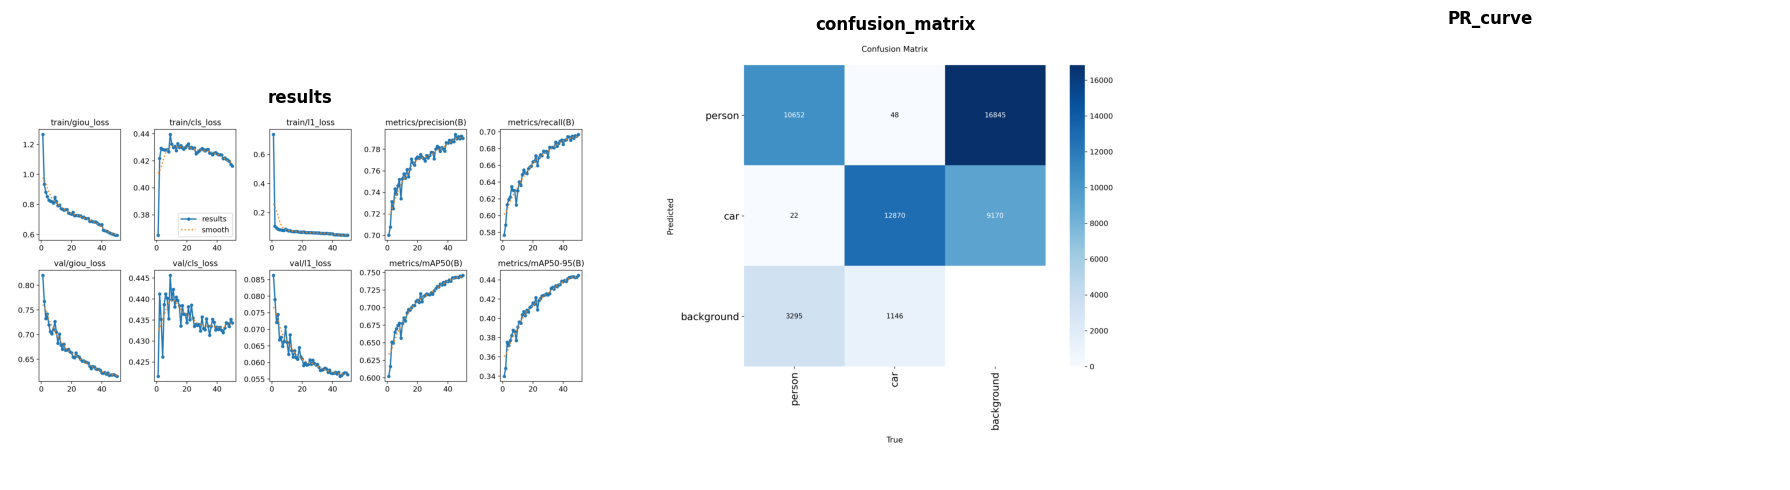

In [7]:
run_dir = Path(PROJECT) / SAVE_NAME
plots_to_show = ['results.png', 'confusion_matrix.png', 'PR_curve.png']
fig, axes = plt.subplots(1, len(plots_to_show), figsize=(18, 5))
for ax, p in zip(axes, plots_to_show):
    fp = run_dir / p
    ax.imshow(mpimg.imread(str(fp))) if fp.exists() else None
    ax.set_title(p.replace('.png', ''), fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()


0: 640x640 71 persons, 26 cars, 54.9ms
1: 640x640 157 persons, 28 cars, 54.9ms
2: 640x640 167 persons, 6 cars, 54.9ms
Speed: 4.5ms preprocess, 54.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/rtdetr_l_visdrone_inference


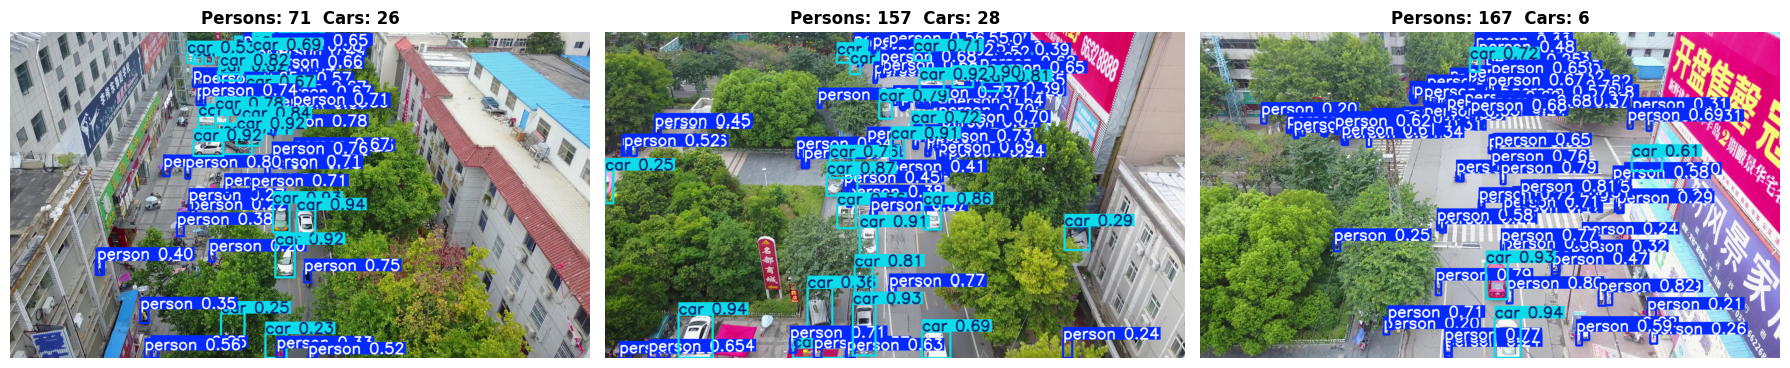

In [8]:
val_img_dir = os.path.join(DATASET_PATH, 'VisDrone2019-DET-val', 'images')
val_imgs = sorted(os.listdir(val_img_dir))[:3]
preds = model_val.predict(
    source=[os.path.join(val_img_dir, f) for f in val_imgs],
    imgsz=IMGSZ, conf=0.20,
    save=True, project=PROJECT, name=SAVE_NAME + '_inference',
)
fig, axes = plt.subplots(1, len(preds), figsize=(18, 6))
for ax, r in zip(axes, preds):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.set_title(f'Persons: {(r.boxes.cls==0).sum().item()}  Cars: {(r.boxes.cls==1).sum().item()}',
                 fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Results & Export

In [9]:
print('=' * 50)
print(f' Model    : {SAVE_NAME}')
print(f' mAP50    : {val_results.box.map50:.4f}')
print(f' mAP50-95 : {val_results.box.map:.4f}')
print(f' Precision: {val_results.box.mp:.4f}')
print(f' Recall   : {val_results.box.mr:.4f}')
print('=' * 50)

dest = f'/kaggle/working/{SAVE_NAME}.pt'
shutil.copy(str(best_weights), dest)
print(f'Weights saved to: {dest}')

 Model    : rtdetr_l_visdrone
 mAP50    : 0.7469
 mAP50-95 : 0.4469
 Precision: 0.7915
 Recall   : 0.6967
Weights saved to: /kaggle/working/rtdetr_l_visdrone.pt


---
## 8. Next Steps

- Download `{SAVE_NAME}.pt` from Kaggle output
- Compare RT-DETR vs YOLO metrics in `Train_Comparison.md`
- Proceed to Phase 4: Evaluation & Tracking